# Chapter 05: Global Differential Geometry

Source orientation: do Carmo, *Differential Geometry of Curves and Surfaces*, Chapter 5, printed pp. 321-474 / PDF pp. 337-490. The point-set topology appendix in the same span is used as supporting language for completeness, compactness, connectedness, and covering maps.

Chapter goal: turn local data--curvature, geodesics, variations, and coordinate changes--into global tests. By the end of the notebook, a learner should be able to explain why hypotheses such as compactness, completeness, simple connectedness, and immersion matter, and should recognize the computational shadows of Hopf-Rinow, Bonnet, Hadamard, Fary-Milnor, the zero-curvature classification, Jacobi's theorem, and Hilbert's obstruction.

This notebook is original teaching prose and code. It uses the source span for orientation only; it does not reproduce textbook figures, exercises, hints, answers, screenshots, or page layouts.

## Computational Translation Guide

| Chapter language | Computational language used here | Inspection target |
| --- | --- | --- |
| Compactness, completeness, nonextendability | geodesic clocks, event detection, metric balls | Does a geodesic run out of surface in finite parameter time? |
| Curvature constrains topology | triangulated surfaces, Euler characteristic, angle defects | Does accumulated discrete curvature match `2*pi*chi`? |
| First and second variations | scalar normal fields and the index form | When does a neighboring curve shorten a geodesic arc? |
| Jacobi fields and conjugate points | ODE `J'' + KJ = 0` along model geodesics | Where does transverse separation vanish again? |
| Covering spaces | sheet graphs, lift endpoints, deck translations | Does a lifted loop close or end on a different sheet? |
| Total curvature of curves | discrete tangent turning of closed space curves | Does a knotted sample exceed the `4*pi` Fary-Milnor threshold? |
| Developable zero-curvature surfaces | symbolic curvature and rotatable ruled surfaces | Which zero-curvature models are complete? |
| Abstract surfaces and Hilbert obstruction | intrinsic metric ledgers and proof dependency graphs | Why can the hyperbolic plane exist intrinsically but not as a complete immersed surface in `R^3`? |

In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp
import trimesh
from scipy.integrate import solve_ivp
from IPython.display import Markdown, display


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / '00-book-index.ipynb').exists() and (candidate / 'utils').exists():
            return candidate
        nested = candidate / 'Differential-Geometry-of-Curves-and-Surfaces'
        if (nested / '00-book-index.ipynb').exists() and (nested / 'utils').exists():
            return nested
    raise FileNotFoundError('Could not locate the do Carmo course root.')

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, assert_artifact, display_artifact, save_figure, save_plotly_html, write_json
from utils.plotting import COURSE_COLORS, equalize_3d_axes, set_course_style

set_course_style()
UNIT = 'chapter-05'
paths = {}
checks = {}


def rel(path):
    return Path(path).relative_to(BOOK_ROOT).as_posix()


def record_path(key, path):
    paths[key] = Path(path)
    return paths[key]

print(f'Book root: {BOOK_ROOT.name}')
print(f'Artifact root: {rel(BOOK_ROOT / "artifacts" / UNIT)}')

Book root: Differential-Geometry-of-Curves-and-Surfaces
Artifact root: artifacts/chapter-05


## Visual Storyboard And Library Routing

This pass keeps the chapter's dependency table in mind but routes each major idea to an inspectable object rather than a decorative picture.

| Storyboard item | Representation | Library choice | Check |
| --- | --- | --- | --- |
| Local curvature becomes global topology | triangulated sphere and torus angle-defect ledger | `trimesh`, Matplotlib | defect sum vs. `2*pi*chi` |
| Completeness and Hopf-Rinow intuition | geodesic ODE clock with event detection | SciPy ODE, Matplotlib | punctured geodesic hits a missing point in finite time |
| Variations, Bonnet, Jacobi fields, conjugate points | model Jacobi ODE and index-form sign | SciPy ODE, Matplotlib | first zero near `pi`; index sign changes at `L=pi` |
| Coverings and Hadamard | sheet-lift diagram and deck-translation graph | NetworkX, Matplotlib | degree-three loop has lift displacement `6*pi` |
| Total curvature and Fary-Milnor | sampled closed curves and discrete tangent turning | NumPy, Matplotlib 3D | trefoil sample exceeds `4*pi` |
| Complete flat surfaces and developables | rotatable plane/cylinder/cone with symbolic `K` | Plotly HTML, SymPy | cylinder and cone have `K=0` away from singular sets |
| Abstract surfaces and Hilbert obstruction | proof-state graph plus hyperbolic area growth ledger | NetworkX, Matplotlib | hyperbolic disk area is unbounded |

In [2]:
storyboard = [
    {'concept': 'curvature topology ledger', 'artifact': 'figures/curvature-topology-angle-defect-ledger.png', 'validation': 'sum defects equals 2*pi*chi'},
    {'concept': 'completeness clock', 'artifact': 'figures/complete-vs-incomplete-geodesic-clock.png', 'validation': 'finite-time deleted-point hit'},
    {'concept': 'Jacobi and conjugate points', 'artifact': 'figures/jacobi-field-curvature-comparison.png', 'validation': 'positive-curvature first conjugate point at pi'},
    {'concept': 'covering lifts', 'artifact': 'figures/covering-lift-sheet-diagnostics.png', 'validation': 'degree-three loop displacement 6*pi'},
    {'concept': 'total curvature obstruction', 'artifact': 'figures/total-curvature-knot-diagnostic.png', 'validation': 'trefoil sample total curvature larger than 4*pi'},
    {'concept': 'zero-curvature developables', 'artifact': 'interactive/zero-curvature-developable-surfaces.html', 'validation': 'symbolic Gaussian curvature is zero away from singular sets'},
    {'concept': 'Hilbert obstruction', 'artifact': 'figures/hilbert-obstruction-area-ledger.png', 'validation': 'hyperbolic disk area grows without bound'},
]
record_path('visual_storyboard', write_json(storyboard, UNIT, 'checks', 'visual-storyboard.json'))
display(Markdown('\n'.join(f"- `{item['artifact']}`: {item['concept']}" for item in storyboard)))

- `figures/curvature-topology-angle-defect-ledger.png`: curvature topology ledger
- `figures/complete-vs-incomplete-geodesic-clock.png`: completeness clock
- `figures/jacobi-field-curvature-comparison.png`: Jacobi and conjugate points
- `figures/covering-lift-sheet-diagnostics.png`: covering lifts
- `figures/total-curvature-knot-diagnostic.png`: total curvature obstruction
- `interactive/zero-curvature-developable-surfaces.html`: zero-curvature developables
- `figures/hilbert-obstruction-area-ledger.png`: Hilbert obstruction

## 1. Local Curvature Can Become A Global Ledger

The opening sections use rigidity of the sphere to set the tone: local curvature is not just a pointwise number once compactness or completeness enters. A mesh angle-defect model is not a proof of rigidity, but it is a concrete proxy for the global bookkeeping behind Gauss-Bonnet. On a triangulated closed surface, each vertex receives the deficit between `2*pi` and the sum of incident face angles. Adding those local defects recovers `2*pi*chi`.

Inspect the two meshes below as a warning about local-to-global reasoning. Both are assembled from tiny local triangles. The sphere accumulates positive total defect; the torus balances positive and negative contributions so that the global total is zero. That global number is topological, not just a local curvature sample.

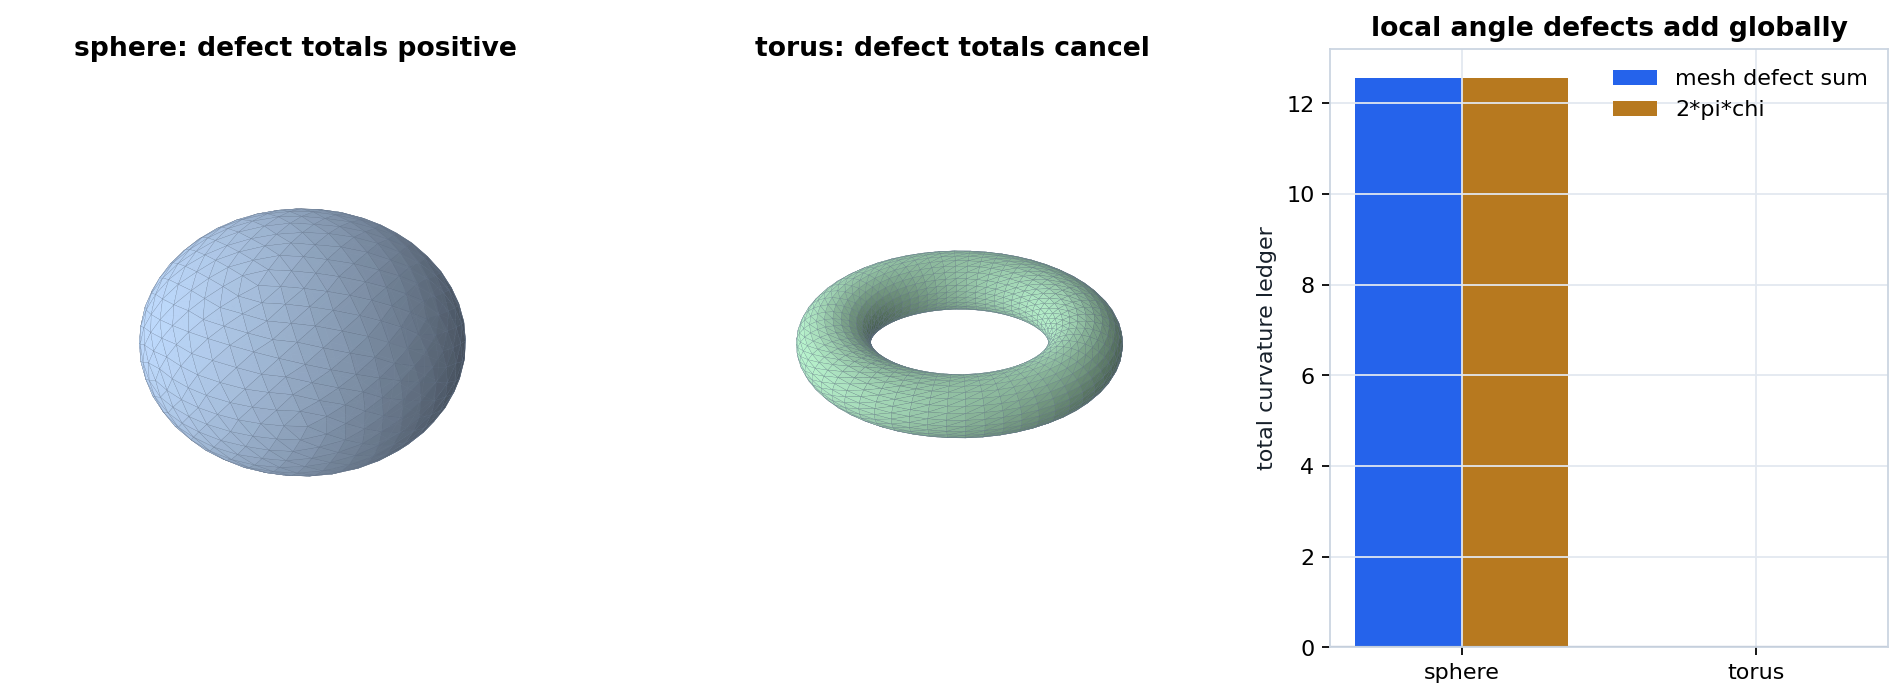

{'sphere': {'vertices': 642,
  'edges': 1920,
  'faces': 1280,
  'euler_characteristic': 2,
  'total_angle_defect': 12.566370614359034,
  'gauss_bonnet_target': 12.566370614359172,
  'absolute_error': 1.3855583347321954e-13},
 'torus': {'vertices': 1568,
  'edges': 4704,
  'faces': 3136,
  'euler_characteristic': 0,
  'total_angle_defect': -4.076183834911262e-13,
  'gauss_bonnet_target': 0.0,
  'absolute_error': 4.076183834911262e-13}}

In [3]:
def triangulated_torus(R=2.1, r=0.62, nu=56, nv=28):
    u = np.linspace(0, 2 * np.pi, nu, endpoint=False)
    v = np.linspace(0, 2 * np.pi, nv, endpoint=False)
    uu, vv = np.meshgrid(u, v, indexing='ij')
    vertices = np.column_stack([
        ((R + r * np.cos(vv)) * np.cos(uu)).ravel(),
        ((R + r * np.cos(vv)) * np.sin(uu)).ravel(),
        (r * np.sin(vv)).ravel(),
    ])
    faces = []
    for i in range(nu):
        for j in range(nv):
            a = i * nv + j
            b = ((i + 1) % nu) * nv + j
            c = i * nv + ((j + 1) % nv)
            d = ((i + 1) % nu) * nv + ((j + 1) % nv)
            faces.append([a, b, d])
            faces.append([a, d, c])
    return trimesh.Trimesh(vertices=vertices, faces=np.asarray(faces), process=False)


def angle_defects(mesh):
    vertices = np.asarray(mesh.vertices)
    defects = np.full(len(vertices), 2 * np.pi, dtype=float)
    for face in np.asarray(mesh.faces):
        pts = vertices[face]
        for local_index, vertex_index in enumerate(face):
            p = pts[local_index]
            q = pts[(local_index + 1) % 3]
            r = pts[(local_index + 2) % 3]
            a = q - p
            b = r - p
            cosine = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
            defects[vertex_index] -= math.acos(float(np.clip(cosine, -1.0, 1.0)))
    return defects


def mesh_ledger(mesh):
    V = int(len(mesh.vertices))
    E = int(len(mesh.edges_unique))
    F = int(len(mesh.faces))
    chi = V - E + F
    defects = angle_defects(mesh)
    return {
        'vertices': V,
        'edges': E,
        'faces': F,
        'euler_characteristic': int(chi),
        'total_angle_defect': float(defects.sum()),
        'gauss_bonnet_target': float(2 * np.pi * chi),
        'absolute_error': float(abs(defects.sum() - 2 * np.pi * chi)),
        'defects': defects,
    }

sphere_mesh = trimesh.creation.icosphere(subdivisions=3, radius=1.0)
torus_mesh = triangulated_torus()
mesh_data = {'sphere': mesh_ledger(sphere_mesh), 'torus': mesh_ledger(torus_mesh)}

fig = plt.figure(figsize=(12, 4.5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133)
for ax, mesh, title, color in [
    (ax1, sphere_mesh, 'sphere: defect totals positive', '#bfdbfe'),
    (ax2, torus_mesh, 'torus: defect totals cancel', '#bbf7d0'),
]:
    verts = np.asarray(mesh.vertices)
    faces = np.asarray(mesh.faces)
    ax.plot_trisurf(verts[:, 0], verts[:, 1], verts[:, 2], triangles=faces, color=color, linewidth=0.08, edgecolor='#64748b', alpha=0.92)
    ax.set_title(title)
    equalize_3d_axes(ax, verts[:, 0], verts[:, 1], verts[:, 2])
    ax.set_axis_off()
labels = ['sphere', 'torus']
actual = [mesh_data[name]['total_angle_defect'] for name in labels]
target = [mesh_data[name]['gauss_bonnet_target'] for name in labels]
x = np.arange(len(labels))
ax3.bar(x - 0.18, actual, width=0.36, label='mesh defect sum', color=COURSE_COLORS['blue'])
ax3.bar(x + 0.18, target, width=0.36, label='2*pi*chi', color=COURSE_COLORS['gold'])
ax3.axhline(0, color='#94a3b8', linewidth=1)
ax3.set_xticks(x, labels)
ax3.set_ylabel('total curvature ledger')
ax3.set_title('local angle defects add globally')
ax3.legend()
fig.tight_layout()
record_path('curvature_topology', save_figure(fig, UNIT, 'figures', 'curvature-topology-angle-defect-ledger.png'))
plt.close(fig)

mesh_check = {name: {k: v for k, v in data.items() if k != 'defects'} for name, data in mesh_data.items()}
checks['mesh_angle_defects'] = mesh_check
record_path('mesh_ledger', write_json(mesh_check, UNIT, 'checks', 'mesh-gauss-bonnet-ledger.json'))
display_artifact(paths['curvature_topology'], width=920)
mesh_check

## 2. Completeness And The Hopf-Rinow Clock

Completeness is stronger than saying a surface has no obvious local singularity. The computational test here is deliberately plain: run a geodesic and see whether the model has room to continue it. In the punctured plane, the radial geodesic aimed at the missing point reaches the missing point in finite time. The same differential equation in the whole plane simply continues.

Hopf-Rinow is deeper than this plot: on a complete surface, the intrinsic distance behaves well enough that every pair of points can be joined by a minimizing geodesic. The visual is the diagnostic that motivates the hypothesis. Without completeness, a finite geodesic clock can stop at a point that the surface has deleted.

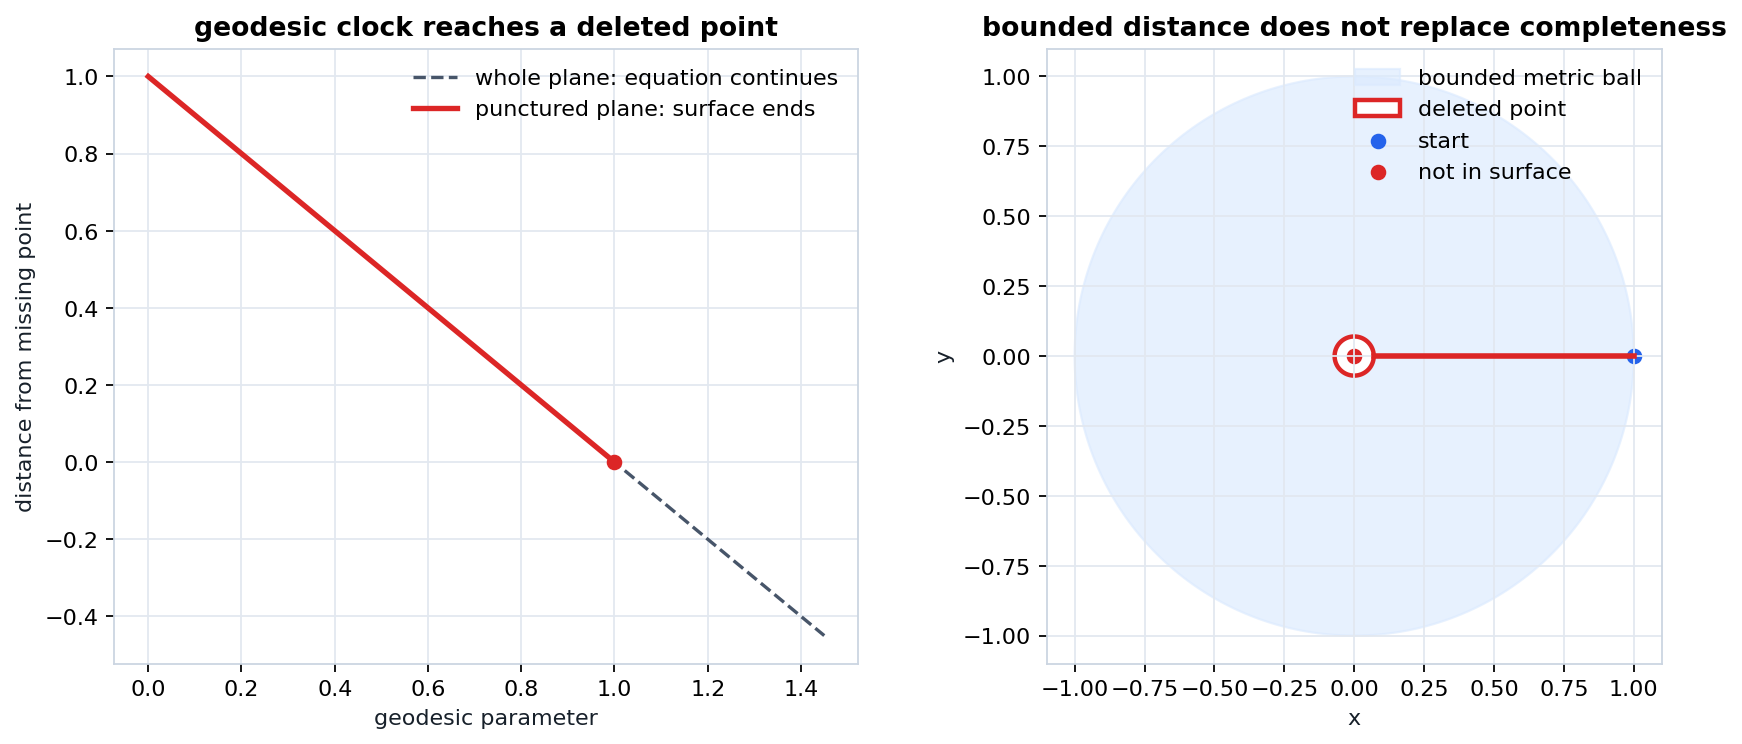

{'punctured_plane_hit_time': 0.9999999999999999,
 'initial_radius': 1.0,
 'finite_time_failure': True,
 'complete_reference_value_at_1_25': -0.2513698630136987}

In [4]:
def inward_radial_geodesic(_t, y):
    return [-1.0]


def hit_missing_point(_t, y):
    return y[0]

hit_missing_point.terminal = True
hit_missing_point.direction = -1
punctured = solve_ivp(inward_radial_geodesic, (0.0, 1.45), [1.0], events=hit_missing_point, max_step=0.01, rtol=1e-10, atol=1e-12)
complete_t = np.linspace(0.0, 1.45, 220)
complete_x = 1.0 - complete_t
hit_time = float(punctured.t_events[0][0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].plot(complete_t, complete_x, color=COURSE_COLORS['slate'], linestyle='--', label='whole plane: equation continues')
axes[0].plot(punctured.t, punctured.y[0], color=COURSE_COLORS['red'], linewidth=2.4, label='punctured plane: surface ends')
axes[0].scatter([hit_time], [0.0], color=COURSE_COLORS['red'], zorder=5)
axes[0].set_title('geodesic clock reaches a deleted point')
axes[0].set_xlabel('geodesic parameter')
axes[0].set_ylabel('distance from missing point')
axes[0].legend()

theta = np.linspace(0, 2 * np.pi, 300)
axes[1].fill(np.cos(theta), np.sin(theta), color='#dbeafe', alpha=0.65, label='bounded metric ball')
axes[1].fill(0.07 * np.cos(theta), 0.07 * np.sin(theta), color='white', edgecolor=COURSE_COLORS['red'], linewidth=2.0, label='deleted point')
axes[1].plot([1.0, 0.07], [0.0, 0.0], color=COURSE_COLORS['red'], linewidth=2.5)
axes[1].scatter([1.0], [0.0], color=COURSE_COLORS['blue'], label='start')
axes[1].scatter([0.0], [0.0], color=COURSE_COLORS['red'], label='not in surface')
axes[1].set_title('bounded distance does not replace completeness')
axes[1].set_aspect('equal')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend(loc='upper right')
fig.tight_layout()
record_path('completeness', save_figure(fig, UNIT, 'figures', 'complete-vs-incomplete-geodesic-clock.png'))
plt.close(fig)

completeness_check = {
    'punctured_plane_hit_time': hit_time,
    'initial_radius': 1.0,
    'finite_time_failure': bool(hit_time < 1.01),
    'complete_reference_value_at_1_25': float(complete_x[np.searchsorted(complete_t, 1.25)]),
}
checks['completeness_clock'] = completeness_check
record_path('completeness_check', write_json(completeness_check, UNIT, 'checks', 'hopf-rinow-completeness-clock.json'))
display_artifact(paths['completeness'], width=900)
completeness_check

## 3. Variations, Jacobi Fields, And Conjugate Points

A variation turns one curve into a family of neighboring curves. For a geodesic, the first variation vanishes under fixed endpoints. The second variation then decides whether a nearby curve can be shorter. Jacobi fields are the infinitesimal separation vectors that come from varying through geodesics.

In a constant-curvature model, a normal Jacobi field with `J(0)=0` and `J'(0)=1` satisfies `J'' + K J = 0`. Positive curvature refocuses neighboring geodesics, zero curvature separates them linearly, and negative curvature separates them faster. A second zero of a nontrivial Jacobi field is a conjugate point; the index-form panel shows why a geodesic segment past that threshold is no longer locally length-minimizing among nearby fixed-endpoint curves.

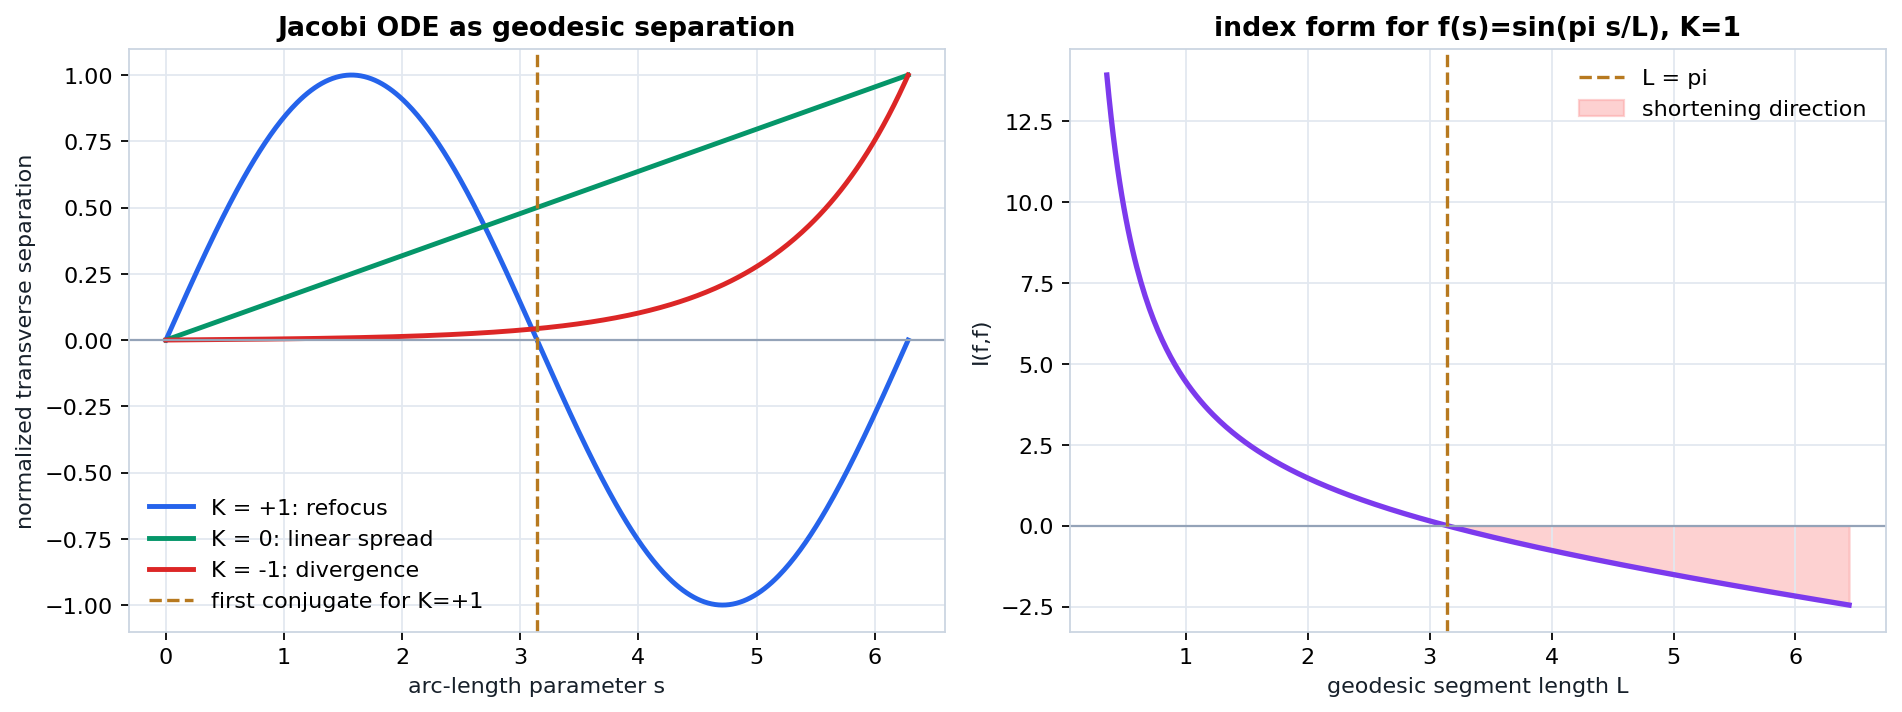

{'first_conjugate_estimate': 3.149090488085234,
 'first_conjugate_exact': 3.141592653589793,
 'estimate_error': 0.007497834495441058,
 'index_at_half_pi': 2.356194490192345,
 'index_at_three_half_pi': -1.3089969389957472,
 'negative_curvature_final_separation_positive': True}

In [5]:
def solve_jacobi(K, s_max=2 * np.pi, n=420):
    def rhs(_s, y):
        return [y[1], -K * y[0]]
    grid = np.linspace(0.0, s_max, n)
    sol = solve_ivp(rhs, (0.0, s_max), [0.0, 1.0], t_eval=grid, rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0]

jacobi_solutions = {K: solve_jacobi(K) for K in [1.0, 0.0, -1.0]}
positive_s, positive_J = jacobi_solutions[1.0]
zero_after_start = np.where((positive_s > 0.25) & (np.signbit(positive_J) != np.signbit(np.roll(positive_J, 1))))[0][0]
first_conjugate_estimate = float(positive_s[zero_after_start])
lengths = np.linspace(0.35, 2.05 * np.pi, 350)
index_values = (np.pi ** 2) / (2 * lengths) - lengths / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
styles = {1.0: ('K = +1: refocus', COURSE_COLORS['blue']), 0.0: ('K = 0: linear spread', COURSE_COLORS['green']), -1.0: ('K = -1: divergence', COURSE_COLORS['red'])}
for K, (s_values, J_values) in jacobi_solutions.items():
    label, color = styles[K]
    scale = max(1.0, np.max(np.abs(J_values)))
    axes[0].plot(s_values, J_values / scale, color=color, linewidth=2.2, label=label)
axes[0].axhline(0, color='#94a3b8', linewidth=1)
axes[0].axvline(np.pi, color=COURSE_COLORS['gold'], linestyle='--', label='first conjugate for K=+1')
axes[0].set_title('Jacobi ODE as geodesic separation')
axes[0].set_xlabel('arc-length parameter s')
axes[0].set_ylabel('normalized transverse separation')
axes[0].legend()
axes[1].plot(lengths, index_values, color=COURSE_COLORS['violet'], linewidth=2.4)
axes[1].axhline(0, color='#94a3b8', linewidth=1)
axes[1].axvline(np.pi, color=COURSE_COLORS['gold'], linestyle='--', label='L = pi')
axes[1].fill_between(lengths, index_values, 0, where=index_values < 0, color='#fca5a5', alpha=0.5, label='shortening direction')
axes[1].set_title('index form for f(s)=sin(pi s/L), K=1')
axes[1].set_xlabel('geodesic segment length L')
axes[1].set_ylabel('I(f,f)')
axes[1].legend()
fig.tight_layout()
record_path('jacobi', save_figure(fig, UNIT, 'figures', 'jacobi-field-curvature-comparison.png'))
plt.close(fig)

jacobi_check = {
    'first_conjugate_estimate': first_conjugate_estimate,
    'first_conjugate_exact': float(np.pi),
    'estimate_error': float(abs(first_conjugate_estimate - np.pi)),
    'index_at_half_pi': float((np.pi ** 2) / (2 * (0.5 * np.pi)) - (0.5 * np.pi) / 2),
    'index_at_three_half_pi': float((np.pi ** 2) / (2 * (1.5 * np.pi)) - (1.5 * np.pi) / 2),
    'negative_curvature_final_separation_positive': bool(jacobi_solutions[-1.0][1][-1] > 0),
}
checks['jacobi_conjugate'] = jacobi_check
record_path('jacobi_check', write_json(jacobi_check, UNIT, 'checks', 'jacobi-conjugate-points.json'))
display_artifact(paths['jacobi'], width=930)
jacobi_check

## 4. Covering Spaces And The Hadamard Upgrade

The chapter introduces coverings because the exponential map in nonpositive curvature is first obtained as a local diffeomorphism. A local diffeomorphism can still wrap globally. Covering-space language separates the local statement from the global topology needed to unwrap it.

The left panel shows the circle/cylinder covering idea through sheets: a loop closes downstairs but its lift can move from one sheet to the next. The right panel records the same deck translations as a graph. For the circle covering `R -> S^1`, the lift of a degree-three loop ends `6*pi` above where it started.

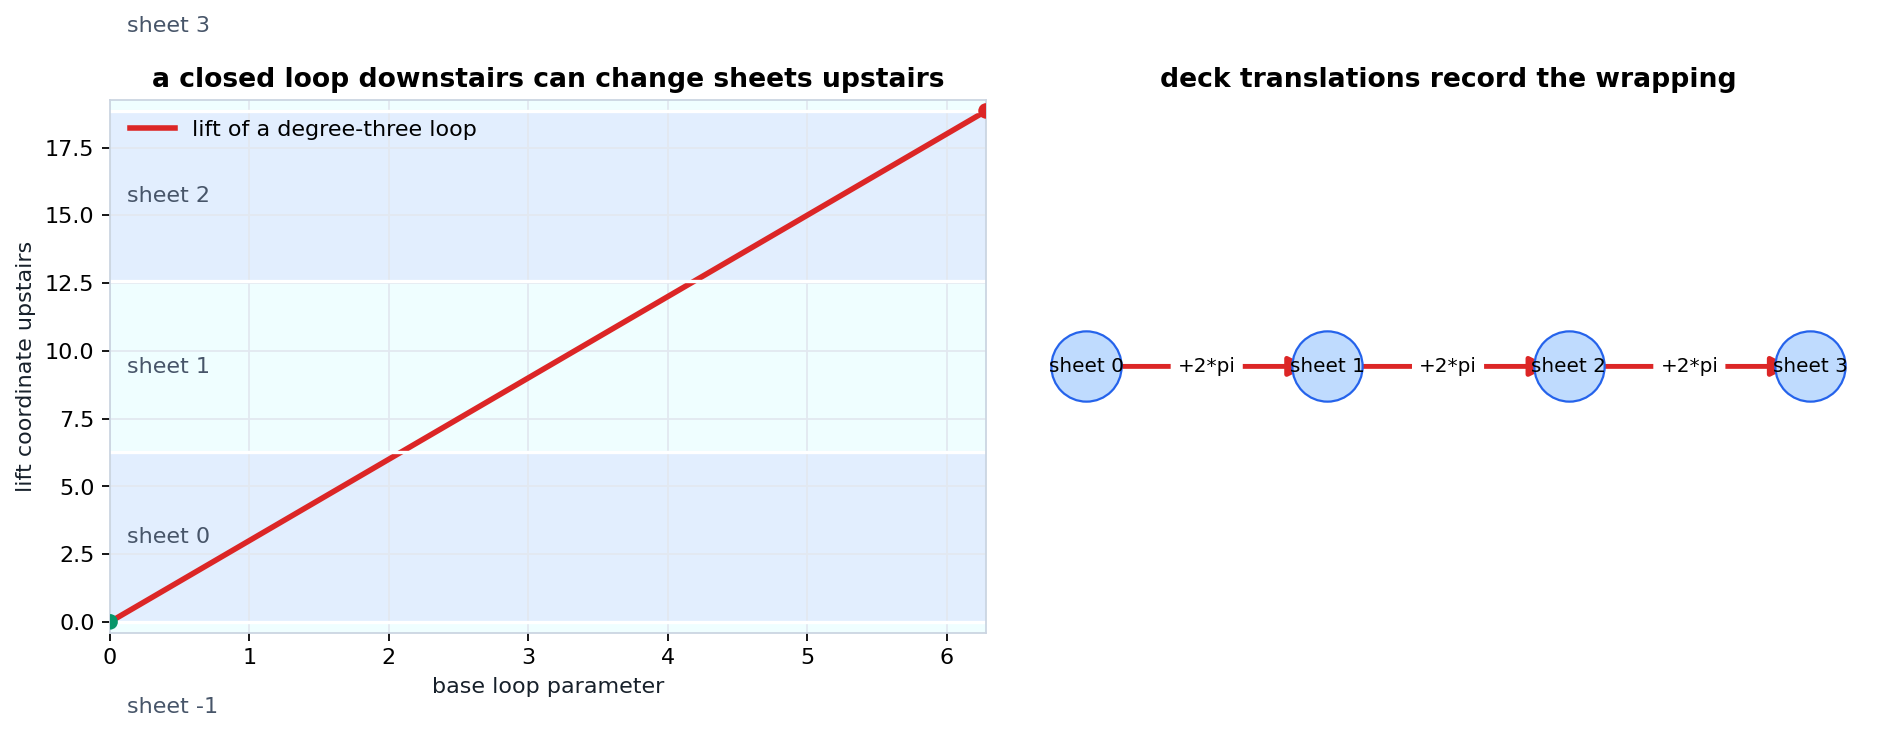

{'circle_cover_degree': 3,
 'lift_start': 0.0,
 'lift_end': 18.84955592153876,
 'lift_displacement': 18.84955592153876,
 'expected_displacement': 18.84955592153876,
 'deck_translation_edges': 3}

In [6]:
t = np.linspace(0, 2 * np.pi, 400)
degree = 3
lift = degree * t
lift_displacement = float(lift[-1] - lift[0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
for k in range(-1, 4):
    y0 = 2 * np.pi * k
    ax.axhspan(y0, y0 + 2 * np.pi, color='#dbeafe' if k % 2 == 0 else '#ecfeff', alpha=0.8)
    ax.text(0.12, y0 + np.pi, f'sheet {k}', va='center', color=COURSE_COLORS['slate'])
ax.plot(t, lift, color=COURSE_COLORS['red'], linewidth=2.5, label='lift of a degree-three loop')
ax.scatter([t[0], t[-1]], [lift[0], lift[-1]], color=[COURSE_COLORS['green'], COURSE_COLORS['red']], zorder=5)
for y in np.arange(-2 * np.pi, 9 * np.pi, 2 * np.pi):
    ax.axhline(y, color='white', linewidth=1.5)
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-0.4, 6 * np.pi + 0.4)
ax.set_xlabel('base loop parameter')
ax.set_ylabel('lift coordinate upstairs')
ax.set_title('a closed loop downstairs can change sheets upstairs')
ax.legend(loc='upper left')

G = nx.DiGraph()
for sheet in range(4):
    G.add_node(sheet)
for sheet in range(3):
    G.add_edge(sheet, sheet + 1, label='+2*pi')
pos = {sheet: (sheet, 0) for sheet in range(4)}
nx.draw_networkx_nodes(G, pos, ax=axes[1], node_color='#bfdbfe', edgecolors=COURSE_COLORS['blue'], node_size=1000)
nx.draw_networkx_labels(G, pos, ax=axes[1], labels={s: f'sheet {s}' for s in G.nodes}, font_size=9)
nx.draw_networkx_edges(G, pos, ax=axes[1], arrows=True, arrowstyle='-|>', arrowsize=18, edge_color=COURSE_COLORS['red'], width=2.2)
nx.draw_networkx_edge_labels(G, pos, ax=axes[1], edge_labels=nx.get_edge_attributes(G, 'label'), font_size=9)
axes[1].set_title('deck translations record the wrapping')
axes[1].set_axis_off()
fig.tight_layout()
record_path('covering', save_figure(fig, UNIT, 'figures', 'covering-lift-sheet-diagnostics.png'))
plt.close(fig)

covering_check = {
    'circle_cover_degree': degree,
    'lift_start': float(lift[0]),
    'lift_end': float(lift[-1]),
    'lift_displacement': lift_displacement,
    'expected_displacement': float(degree * 2 * np.pi),
    'deck_translation_edges': int(G.number_of_edges()),
}
checks['covering_lift'] = covering_check
record_path('covering_check', write_json(covering_check, UNIT, 'checks', 'covering-lift-ledger.json'))
display_artifact(paths['covering'], width=930)
covering_check

## 5. Total Curvature As A Global Curve Obstruction

For closed curves, the chapter moves from surfaces back to a one-dimensional global theorem. Total curvature is the accumulated turning of the unit tangent. A circle has total curvature `2*pi`; a simple closed plane curve cannot do better. The Fary-Milnor theorem says a knotted simple closed space curve must have total curvature greater than `4*pi`.

The computation below samples three closed curves and sums the turning angles of consecutive unit tangent vectors. This is a numerical diagnostic, not a knot classifier. Its role is to make the theorem's scale visible: the trefoil-like sample has to spend more turning budget than a convex planar loop.

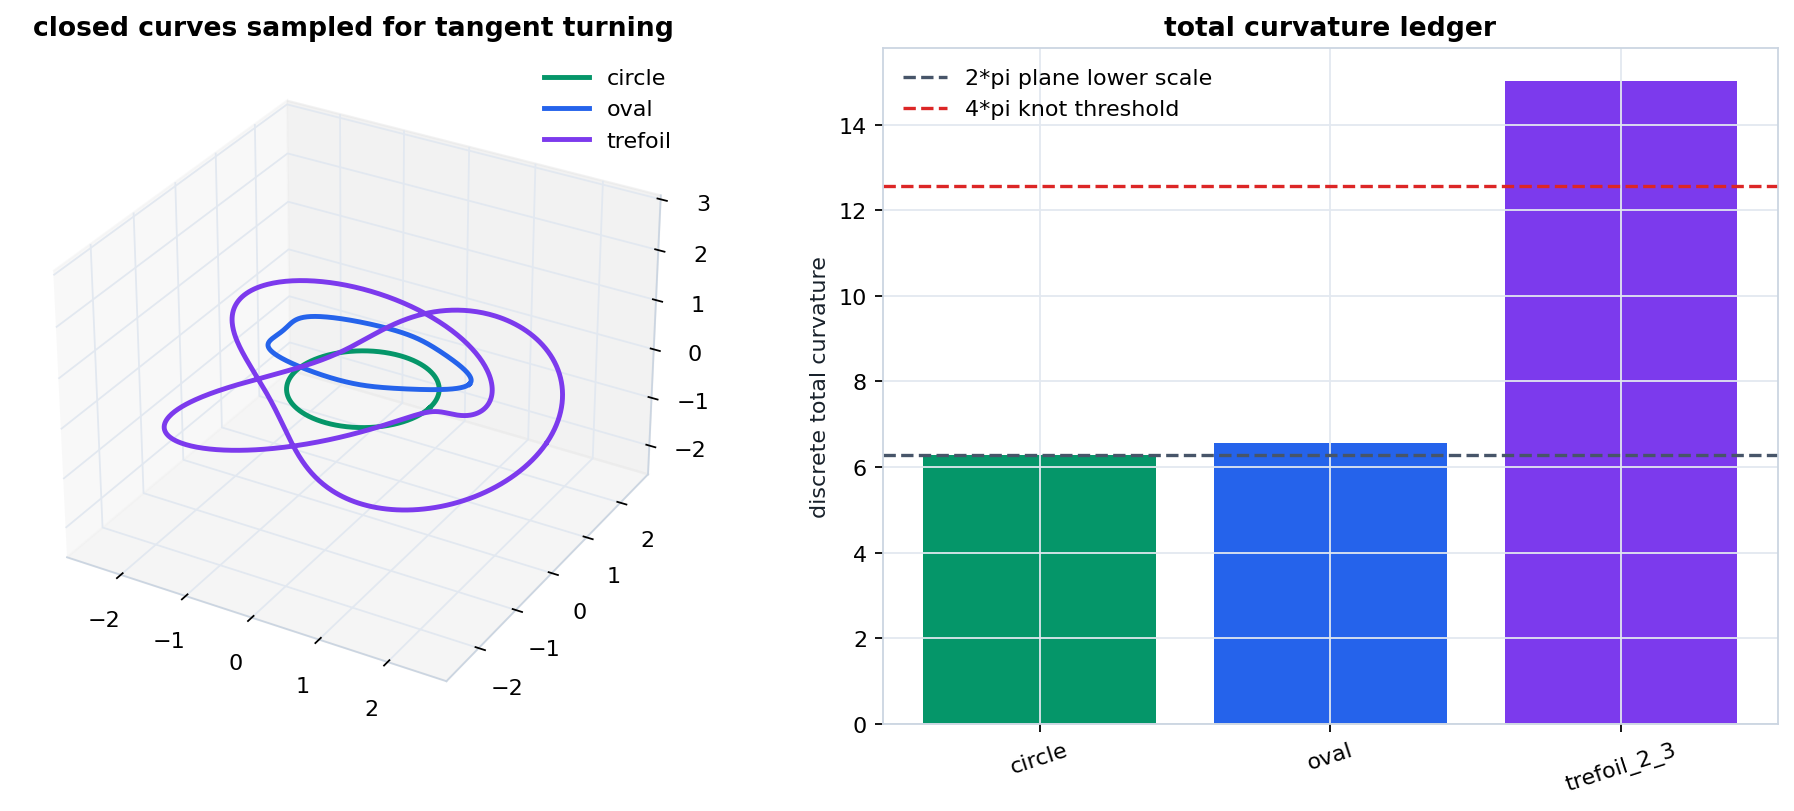

{'samples_per_curve': 900,
 'circle_total_curvature': 6.283185307179144,
 'oval_total_curvature': 6.556403639456685,
 'trefoil_total_curvature': 15.029190330874133,
 'two_pi': 6.283185307179586,
 'four_pi': 12.566370614359172,
 'trefoil_exceeds_four_pi': True,
 'circle_error_from_two_pi': 4.4231285301066237e-13}

In [7]:
def closed_polyline_total_curvature(points):
    edges = np.roll(points, -1, axis=0) - points
    tangents = edges / np.linalg.norm(edges, axis=1, keepdims=True)
    dots = np.sum(tangents * np.roll(tangents, -1, axis=0), axis=1)
    return float(np.sum(np.arccos(np.clip(dots, -1.0, 1.0))))

samples = np.linspace(0, 2 * np.pi, 900, endpoint=False)
circle = np.column_stack([np.cos(samples), np.sin(samples), np.zeros_like(samples)])
oval = np.column_stack([(1.4 + 0.18 * np.cos(3 * samples)) * np.cos(samples), 0.75 * np.sin(samples), np.zeros_like(samples)])
trefoil = np.column_stack([
    (2.0 + 0.72 * np.cos(3 * samples)) * np.cos(2 * samples),
    (2.0 + 0.72 * np.cos(3 * samples)) * np.sin(2 * samples),
    0.72 * np.sin(3 * samples),
])
curves = {'circle': circle, 'oval': oval, 'trefoil_2_3': trefoil}
total_curvatures = {name: closed_polyline_total_curvature(points) for name, points in curves.items()}

fig = plt.figure(figsize=(12, 5.2))
ax1 = fig.add_subplot(121, projection='3d')
for name, points, color in [
    ('circle', circle, COURSE_COLORS['green']),
    ('oval', oval + np.array([0, 0, 0.7]), COURSE_COLORS['blue']),
    ('trefoil', trefoil, COURSE_COLORS['violet']),
]:
    ax1.plot(points[:, 0], points[:, 1], points[:, 2], linewidth=2.2, color=color, label=name)
ax1.set_title('closed curves sampled for tangent turning')
all_points = np.vstack([circle, oval + np.array([0, 0, 0.7]), trefoil])
equalize_3d_axes(ax1, all_points[:, 0], all_points[:, 1], all_points[:, 2])
ax1.legend()
ax2 = fig.add_subplot(122)
labels = list(total_curvatures)
values = [total_curvatures[name] for name in labels]
ax2.bar(labels, values, color=[COURSE_COLORS['green'], COURSE_COLORS['blue'], COURSE_COLORS['violet']])
ax2.axhline(2 * np.pi, color=COURSE_COLORS['slate'], linestyle='--', label='2*pi plane lower scale')
ax2.axhline(4 * np.pi, color=COURSE_COLORS['red'], linestyle='--', label='4*pi knot threshold')
ax2.set_title('total curvature ledger')
ax2.set_ylabel('discrete total curvature')
ax2.tick_params(axis='x', rotation=18)
ax2.legend()
fig.tight_layout()
record_path('total_curvature', save_figure(fig, UNIT, 'figures', 'total-curvature-knot-diagnostic.png'))
plt.close(fig)

total_curvature_check = {
    'samples_per_curve': int(len(samples)),
    'circle_total_curvature': total_curvatures['circle'],
    'oval_total_curvature': total_curvatures['oval'],
    'trefoil_total_curvature': total_curvatures['trefoil_2_3'],
    'two_pi': float(2 * np.pi),
    'four_pi': float(4 * np.pi),
    'trefoil_exceeds_four_pi': bool(total_curvatures['trefoil_2_3'] > 4 * np.pi),
    'circle_error_from_two_pi': float(abs(total_curvatures['circle'] - 2 * np.pi)),
}
checks['total_curvature'] = total_curvature_check
record_path('total_curvature_check', write_json(total_curvature_check, UNIT, 'checks', 'total-curvature-ledger.json'))
display_artifact(paths['total_curvature'], width=930)
total_curvature_check

## 6. Complete Flat Surfaces And Developable Models

Surfaces with `K=0` are locally plane-like, but the chapter's theorem is global: a complete regular surface in `R^3` with zero Gaussian curvature is a plane or a cylinder. Local flatness alone would also allow a cone away from its vertex, so the missing vertex is the computational warning sign.

The symbolic check confirms zero Gaussian curvature for a cylinder and a cone away from the cone tip. The rotatable HTML artifact then shows why the theorem is not merely local: the cone has the same local `K=0` behavior away from the tip, but a generator reaches the deleted vertex in finite time.

In [8]:
u = sp.symbols('u', real=True)
r = sp.symbols('r', positive=True)
a = sp.symbols('a', positive=True)
z = sp.symbols('z', real=True)


def gaussian_curvature_param(X, p, q):
    Xu = X.diff(p)
    Xv = X.diff(q)
    normal = Xu.cross(Xv)
    unit_normal = normal / sp.sqrt(sp.simplify(normal.dot(normal)))
    E = sp.simplify(Xu.dot(Xu))
    F = sp.simplify(Xu.dot(Xv))
    G = sp.simplify(Xv.dot(Xv))
    e = sp.simplify(unit_normal.dot(Xu.diff(p)))
    f = sp.simplify(unit_normal.dot(Xu.diff(q)))
    g = sp.simplify(unit_normal.dot(Xv.diff(q)))
    return sp.simplify((e * g - f ** 2) / (E * G - F ** 2))

K_cylinder = sp.simplify(gaussian_curvature_param(sp.Matrix([sp.cos(u), sp.sin(u), z]), u, z))
K_cone = sp.simplify(gaussian_curvature_param(sp.Matrix([r * sp.cos(u), r * sp.sin(u), a * r]), u, r))

uu = np.linspace(0, 2 * np.pi, 80)
vv = np.linspace(-1.7, 1.7, 50)
UU, VV = np.meshgrid(uu, vv, indexing='ij')
plane = np.stack([UU / np.pi - 1.0, VV, np.zeros_like(UU)], axis=-1)
cylinder = np.stack([np.cos(UU) + 3.2, np.sin(UU), VV], axis=-1)
cone_radius = np.linspace(0.08, 1.75, 55)
CU, CR = np.meshgrid(uu, cone_radius, indexing='ij')
cone = np.stack([CR * np.cos(CU) - 3.2, CR * np.sin(CU), 0.65 * CR - 0.9], axis=-1)

fig = go.Figure()
fig.add_trace(go.Surface(x=plane[..., 0], y=plane[..., 1], z=plane[..., 2], colorscale='Greens', opacity=0.78, showscale=False, name='plane'))
fig.add_trace(go.Surface(x=cylinder[..., 0], y=cylinder[..., 1], z=cylinder[..., 2], colorscale='Blues', opacity=0.82, showscale=False, name='cylinder'))
fig.add_trace(go.Surface(x=cone[..., 0], y=cone[..., 1], z=cone[..., 2], colorscale='Oranges', opacity=0.86, showscale=False, name='cone without tip'))
for angle in np.linspace(0, 2 * np.pi, 9, endpoint=False):
    rr = np.linspace(0.08, 1.75, 50)
    fig.add_trace(go.Scatter3d(x=rr * np.cos(angle) - 3.2, y=rr * np.sin(angle), z=0.65 * rr - 0.9, mode='lines', line={'color': '#7c2d12', 'width': 3}, showlegend=False))
for angle in np.linspace(0, 2 * np.pi, 8, endpoint=False):
    zz = np.linspace(-1.7, 1.7, 60)
    fig.add_trace(go.Scatter3d(x=np.full_like(zz, np.cos(angle) + 3.2), y=np.full_like(zz, np.sin(angle)), z=zz, mode='lines', line={'color': '#1e3a8a', 'width': 3}, showlegend=False))
fig.add_trace(go.Scatter3d(x=[-3.2], y=[0], z=[-0.9], mode='markers+text', marker={'size': 5, 'color': '#dc2626'}, text=['deleted cone tip'], textposition='bottom center', name='missing point'))
fig.update_layout(title='Zero Gaussian curvature: local flatness plus global completeness test', scene={'aspectmode': 'data'}, margin={'l': 0, 'r': 0, 't': 45, 'b': 0})
record_path('developables_html', save_plotly_html(fig, UNIT, 'interactive', 'zero-curvature-developable-surfaces.html'))

developable_check = {
    'symbolic_K_cylinder': str(K_cylinder),
    'symbolic_K_cone_away_from_tip': str(K_cone),
    'cone_inner_radius_used': float(cone_radius.min()),
    'cone_tip_deleted': True,
    'complete_zero_curvature_models_highlighted': ['plane', 'cylinder'],
}
checks['developables'] = developable_check
record_path('developables_check', write_json(developable_check, UNIT, 'checks', 'developable-zero-curvature.json'))
display_artifact(paths['developables_html'], height=560)
developable_check

{'symbolic_K_cylinder': '0',
 'symbolic_K_cone_away_from_tip': '0',
 'cone_inner_radius_used': 0.08,
 'cone_tip_deleted': True,
 'complete_zero_curvature_models_highlighted': ['plane', 'cylinder']}

## 7. Abstract Surfaces And Hilbert's Obstruction

The abstract-surface section removes the assumption that a surface already sits in `R^3`. This matters because the hyperbolic plane is a complete geometric surface with constant negative curvature, but Hilbert's theorem says it cannot be isometrically immersed in `R^3` as a complete surface.

The proof ledger below separates intrinsic facts from extrinsic consequences. Completeness and `K=-1` give an intrinsic hyperbolic plane with unbounded area growth. An isometric immersion would supply asymptotic coordinates forming a Tchebyshev net; the proof then boxes the immersion into finite-area quadrilateral behavior incompatible with the complete hyperbolic area budget.

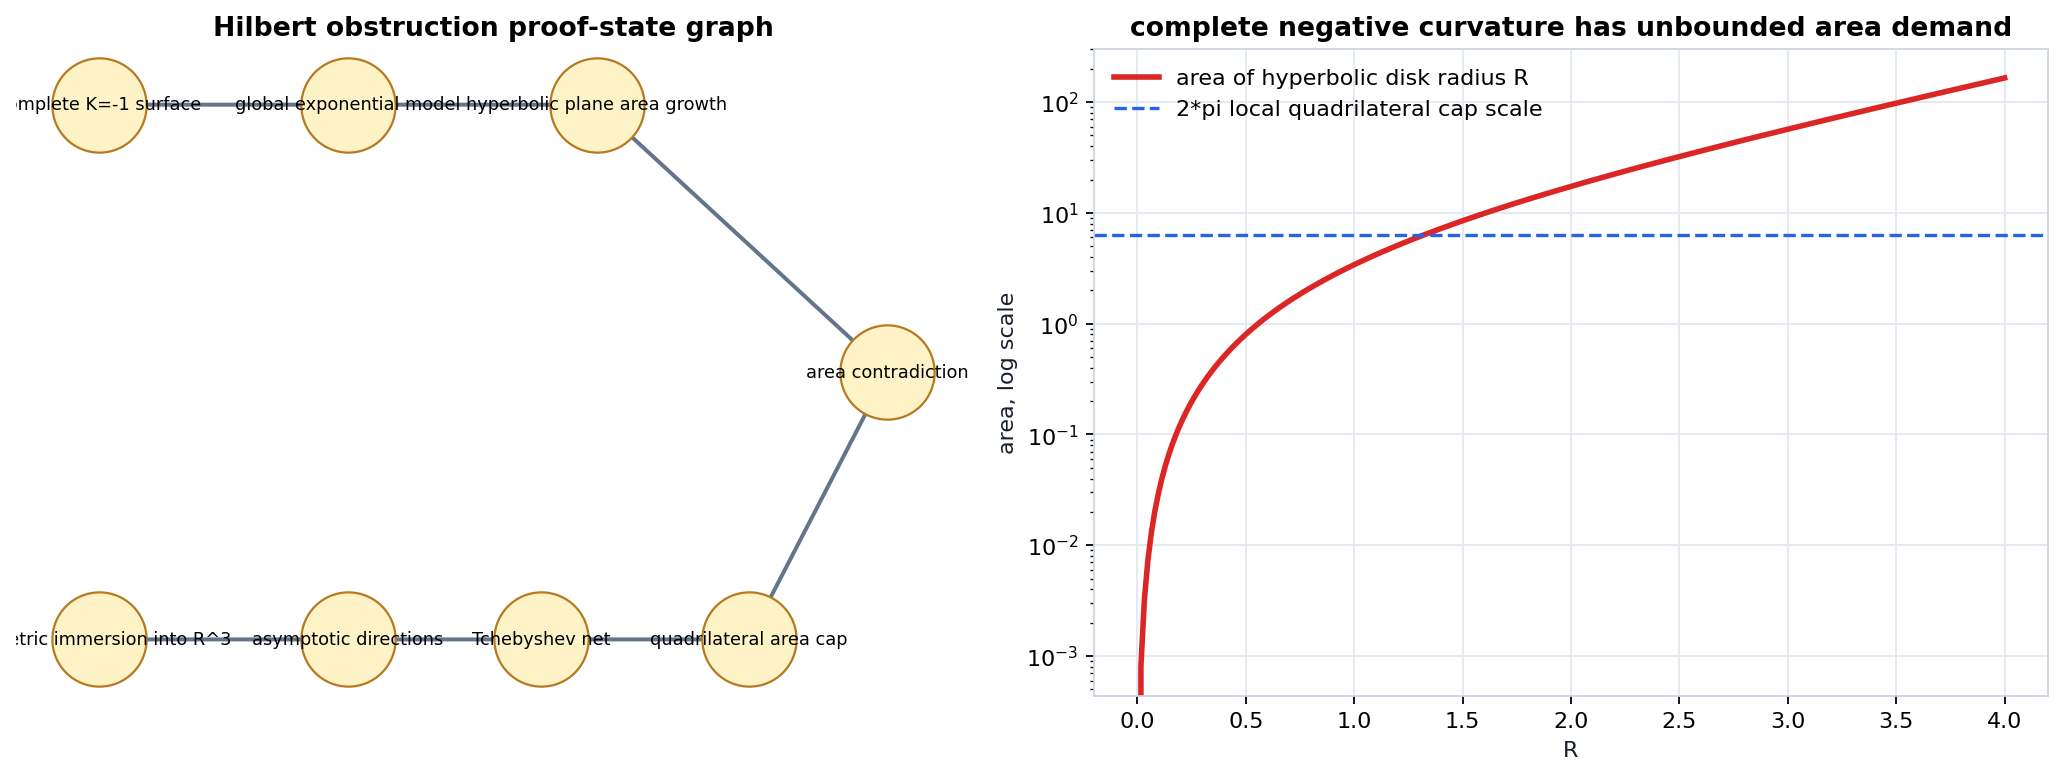

{'area_radius_1': 3.412276265284902,
 'area_radius_4': 165.2995020131183,
 'quadrilateral_cap_scale': 6.283185307179586,
 'area_radius_4_exceeds_100': True,
 'dependency_graph_nodes': 8,
 'dependency_graph_edges': 7}

In [9]:
R_values = np.linspace(0.0, 4.0, 250)
hyperbolic_disk_area = 2 * np.pi * (np.cosh(R_values) - 1.0)
quadrilateral_cap = 2 * np.pi
G = nx.DiGraph()
G.add_edges_from([
    ('complete K=-1 surface', 'global exponential model'),
    ('global exponential model', 'hyperbolic plane area growth'),
    ('isometric immersion into R^3', 'asymptotic directions'),
    ('asymptotic directions', 'Tchebyshev net'),
    ('Tchebyshev net', 'quadrilateral area cap'),
    ('hyperbolic plane area growth', 'area contradiction'),
    ('quadrilateral area cap', 'area contradiction'),
])
pos = {
    'complete K=-1 surface': (0.0, 1.0),
    'global exponential model': (1.8, 1.0),
    'hyperbolic plane area growth': (3.6, 1.0),
    'isometric immersion into R^3': (0.0, -0.6),
    'asymptotic directions': (1.8, -0.6),
    'Tchebyshev net': (3.2, -0.6),
    'quadrilateral area cap': (4.7, -0.6),
    'area contradiction': (5.7, 0.2),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
nx.draw_networkx_edges(G, pos, ax=axes[0], arrows=True, arrowstyle='-|>', arrowsize=14, width=1.8, edge_color='#64748b')
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color='#fef3c7', edgecolors=COURSE_COLORS['gold'], node_size=1800)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=8)
axes[0].set_title('Hilbert obstruction proof-state graph')
axes[0].set_axis_off()
axes[1].plot(R_values, hyperbolic_disk_area, color=COURSE_COLORS['red'], linewidth=2.5, label='area of hyperbolic disk radius R')
axes[1].axhline(quadrilateral_cap, color=COURSE_COLORS['blue'], linestyle='--', label='2*pi local quadrilateral cap scale')
axes[1].set_yscale('log')
axes[1].set_xlabel('R')
axes[1].set_ylabel('area, log scale')
axes[1].set_title('complete negative curvature has unbounded area demand')
axes[1].legend()
fig.tight_layout()
record_path('hilbert_obstruction', save_figure(fig, UNIT, 'figures', 'hilbert-obstruction-area-ledger.png'))
plt.close(fig)

hilbert_check = {
    'area_radius_1': float(2 * np.pi * (np.cosh(1.0) - 1.0)),
    'area_radius_4': float(2 * np.pi * (np.cosh(4.0) - 1.0)),
    'quadrilateral_cap_scale': float(quadrilateral_cap),
    'area_radius_4_exceeds_100': bool(2 * np.pi * (np.cosh(4.0) - 1.0) > 100),
    'dependency_graph_nodes': int(G.number_of_nodes()),
    'dependency_graph_edges': int(G.number_of_edges()),
}
checks['hilbert_obstruction'] = hilbert_check
record_path('hilbert_check', write_json(hilbert_check, UNIT, 'checks', 'hilbert-obstruction-ledger.json'))
display_artifact(paths['hilbert_obstruction'], width=940)
hilbert_check

## Applied Lab: Change Curvature, Predict The Global Failure Mode

Use this cell as a small lab rather than a hidden test. Change `curvature_values` or the `bonnet_deltas` list and rerun the cell. The output table asks two questions: whether the model Jacobi equation refocuses at a finite conjugate distance, and what Bonnet diameter bound `pi/sqrt(delta)` would follow from a lower curvature bound `K >= delta > 0`.

The table is saved as an artifact so later sanity checks can verify that the lab is reproducible.

In [10]:
curvature_values = [-1.0, 0.0, 0.25, 1.0, 4.0]
bonnet_deltas = [0.25, 1.0, 4.0]
lab_rows = []
for K in curvature_values:
    if K > 0:
        first_zero = np.pi / np.sqrt(K)
        behavior = 'finite conjugate distance'
    elif K == 0:
        first_zero = math.inf
        behavior = 'linear separation, no second zero'
    else:
        first_zero = math.inf
        behavior = 'divergence, no second zero'
    lab_rows.append({'model': f'Jacobi K={K:g}', 'value': K, 'prediction': behavior, 'scale': first_zero})
for delta in bonnet_deltas:
    lab_rows.append({'model': f'Bonnet lower bound delta={delta:g}', 'value': delta, 'prediction': 'diameter <= pi/sqrt(delta)', 'scale': np.pi / np.sqrt(delta)})

lab_path = artifact_path(UNIT, 'tables', 'applied-lab-curvature-thresholds.csv')
with lab_path.open('w', encoding='utf-8', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=['model', 'value', 'prediction', 'scale'])
    writer.writeheader()
    writer.writerows(lab_rows)
record_path('applied_lab_table', lab_path)
checks['applied_lab'] = {'row_count': len(lab_rows), 'positive_curvature_first_zero_K1': float(np.pi), 'bonnet_bound_delta_1': float(np.pi)}
record_path('applied_lab_check', write_json(checks['applied_lab'], UNIT, 'checks', 'applied-lab-curvature-thresholds.json'))
display(Markdown('| model | prediction | scale |\n| --- | --- | ---: |\n' + '\n'.join(f"| {row['model']} | {row['prediction']} | {row['scale']:.6g} |" for row in lab_rows)))

| model | prediction | scale |
| --- | --- | ---: |
| Jacobi K=-1 | divergence, no second zero | inf |
| Jacobi K=0 | linear separation, no second zero | inf |
| Jacobi K=0.25 | finite conjugate distance | 6.28319 |
| Jacobi K=1 | finite conjugate distance | 3.14159 |
| Jacobi K=4 | finite conjugate distance | 1.5708 |
| Bonnet lower bound delta=0.25 | diameter <= pi/sqrt(delta) | 6.28319 |
| Bonnet lower bound delta=1 | diameter <= pi/sqrt(delta) | 3.14159 |
| Bonnet lower bound delta=4 | diameter <= pi/sqrt(delta) | 1.5708 |

## Final Sanity Checks

The final cell checks both artifact integrity and chapter identities. The identities are intentionally varied: a mesh Gauss-Bonnet ledger, a finite-time completeness failure, a Jacobi conjugate point, a covering lift displacement, a total-curvature threshold, symbolic zero Gaussian curvature, and hyperbolic area growth.

In [11]:
for key, path in sorted(paths.items()):
    min_bytes = 64 if Path(path).suffix.lower() in {'.json', '.csv'} else 1024
    assert_artifact(path, min_bytes=min_bytes)

assert checks['mesh_angle_defects']['sphere']['euler_characteristic'] == 2
assert checks['mesh_angle_defects']['torus']['euler_characteristic'] == 0
assert checks['mesh_angle_defects']['sphere']['absolute_error'] < 1e-10
assert checks['mesh_angle_defects']['torus']['absolute_error'] < 1e-10
assert abs(checks['completeness_clock']['punctured_plane_hit_time'] - 1.0) < 1e-8
assert checks['completeness_clock']['finite_time_failure']
assert abs(checks['jacobi_conjugate']['first_conjugate_exact'] - np.pi) < 1e-12
assert checks['jacobi_conjugate']['index_at_half_pi'] > 0
assert checks['jacobi_conjugate']['index_at_three_half_pi'] < 0
assert abs(checks['covering_lift']['lift_displacement'] - checks['covering_lift']['expected_displacement']) < 1e-9
assert checks['total_curvature']['trefoil_exceeds_four_pi']
assert checks['total_curvature']['circle_error_from_two_pi'] < 0.02
assert checks['developables']['symbolic_K_cylinder'] == '0'
assert checks['developables']['symbolic_K_cone_away_from_tip'] == '0'
assert checks['hilbert_obstruction']['area_radius_4_exceeds_100']
assert checks['applied_lab']['row_count'] == 8

artifact_sizes = {key: Path(path).stat().st_size for key, path in sorted(paths.items())}
final_sanity = {
    'unit': UNIT,
    'source_span': 'printed pp. 321-474 / PDF pp. 337-490',
    'artifact_count': len(paths),
    'artifact_paths': {key: rel(path) for key, path in sorted(paths.items())},
    'artifact_sizes': artifact_sizes,
    'core_checks': checks,
}
record_path('final_sanity', write_json(final_sanity, UNIT, 'checks', 'final-sanity.json'))
assert_artifact(paths['final_sanity'], min_bytes=1024)
display(Markdown(f"Final sanity passed with **{len(paths)}** artifacts/check files tracked."))
final_sanity

Final sanity passed with **18** artifacts/check files tracked.

{'unit': 'chapter-05',
 'source_span': 'printed pp. 321-474 / PDF pp. 337-490',
 'artifact_count': 17,
 'artifact_paths': {'applied_lab_check': 'artifacts/chapter-05/checks/applied-lab-curvature-thresholds.json',
  'applied_lab_table': 'artifacts/chapter-05/tables/applied-lab-curvature-thresholds.csv',
  'completeness': 'artifacts/chapter-05/figures/complete-vs-incomplete-geodesic-clock.png',
  'completeness_check': 'artifacts/chapter-05/checks/hopf-rinow-completeness-clock.json',
  'covering': 'artifacts/chapter-05/figures/covering-lift-sheet-diagnostics.png',
  'covering_check': 'artifacts/chapter-05/checks/covering-lift-ledger.json',
  'curvature_topology': 'artifacts/chapter-05/figures/curvature-topology-angle-defect-ledger.png',
  'developables_check': 'artifacts/chapter-05/checks/developable-zero-curvature.json',
  'developables_html': 'artifacts/chapter-05/interactive/zero-curvature-developable-surfaces.html',
  'hilbert_check': 'artifacts/chapter-05/checks/hilbert-obstruction-l

## Takeaways

- Global differential geometry begins when local formulas are paired with hypotheses such as compactness, completeness, and simple connectedness.
- Completeness is a geodesic extension promise; Hopf-Rinow turns that promise into minimizing geodesics and compactness consequences.
- Variations and Jacobi fields translate curvature into focusing, divergence, conjugate points, and loss of local minimality.
- Covering spaces explain why a local diffeomorphism can still wrap, and why simple connectedness unwraps Hadamard-type conclusions.
- Total curvature is a one-dimensional global obstruction: a knotted closed curve must spend more than `4*pi` of tangent turning.
- Zero Gaussian curvature is locally flat, but the complete global classification in `R^3` leaves only planes and cylinders.
- Abstract surfaces let intrinsic geometry exist without an ambient `R^3`; Hilbert's theorem warns that not every complete intrinsic metric can be realized as a complete immersed surface in Euclidean three-space.